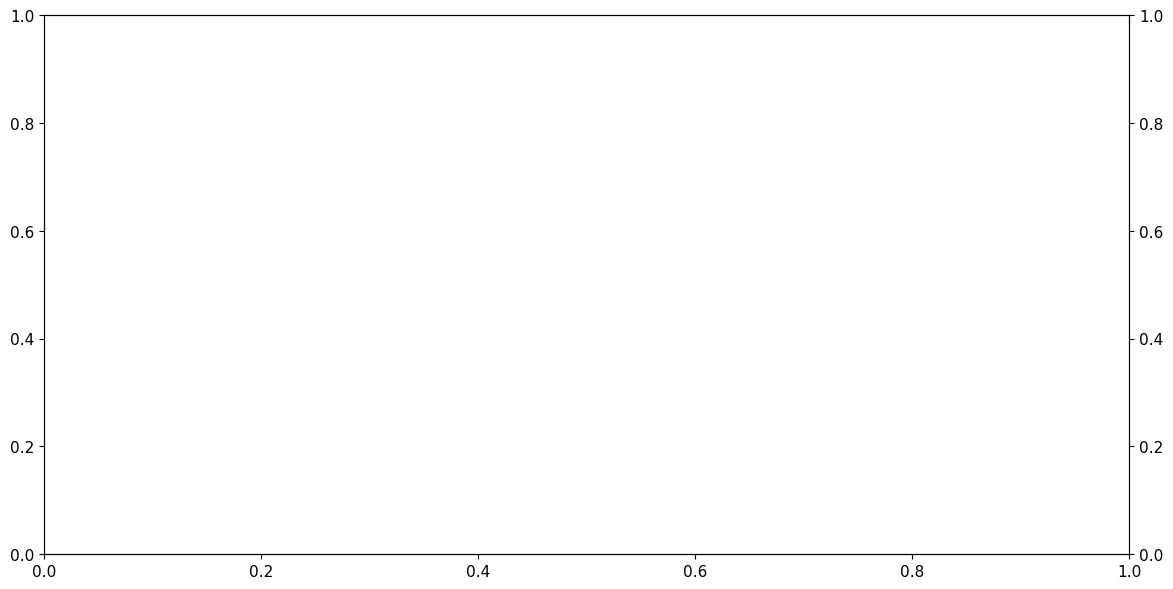

interactive(children=(IntSlider(value=2000, continuous_update=False, description='Start Idx:', max=59800, step…

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact, IntSlider, Checkbox
from IPython.display import display, clear_output

# ==========================================
# 1. 从仿真器生成的 CSV 中加载数据
# ==========================================
try:
    df_cont = pd.read_csv('data/pipeline_continuous.csv')
    final_results = pd.read_csv('data/pipeline_events.csv')
except FileNotFoundError:
    print("❌ 找不到 CSV 文件。请先在终端运行 python run_simulation.py 生成数据！")

# 获取波形数据
y_raw = df_cont['ied'].values
motion = df_cont['motion'].values
y_ac = df_cont['ac_y'].values

# 获取打点索引
peaks_idx_comp = final_results['Peak_Index'].dropna().values.astype(int)
valleys_idx_comp = final_results['Valley_Index'].dropna().values.astype(int)
rri_values = final_results['RRI_ms'].dropna().values

peaks_idx_filt = final_results['Filtered_Peak_Index'].dropna().values.astype(int)
valleys_idx_filt = final_results['Filtered_Valley_Index'].dropna().values.astype(int)

# 模拟一个带配置的空对象，为了图表标题能读到延时参数
class MockPipeline:
    FILTER_DELAY = 5.5
pipeline_c = MockPipeline()

# 初始化画布
plt.close('all')
clear_output(wait=True)
plt.ioff()
plt.rcParams['font.size'] = 11
fig, ax1 = plt.subplots(figsize=(14, 7))
ax2 = ax1.twinx()
plt.ion()

# ==========================================
# 2. 交互式绘图函数 (你的原代码，基本未变)
# ==========================================
@interact(
    start=IntSlider(min=0, max=max(0, len(y_raw)-200), step=100, value=2000, description='Start Idx:', continuous_update=False),
    window=IntSlider(min=200, max=5000, step=100, value=600, description='Window:', continuous_update=False),
    show_raw=Checkbox(value=True, description='显示原始信号 (Raw) & 对齐点', indent=False),
    show_ac=Checkbox(value=True, description='显示滤波信号 (AC) & 内部打点', indent=False)
)
def plot_zoom(start=0, window=600, show_raw=True, show_ac=True):

    ax1.cla()
    ax2.cla()

    end = min(start + window, len(y_raw))
    t = np.arange(start, end) / 100.0

    current_raw = y_raw[start:end]
    current_ac = y_ac[start:end]

    raw_mean = np.nanmean(current_raw)
    current_raw_centered = current_raw - raw_mean

    lines_list = []
    labels_list = []

    # --- 图层 A: 原始信号 & 补偿点 ---
    if show_raw:
        l1, = ax1.plot(t, current_raw_centered, '-', color='#1f77b4', linewidth=1.5, alpha=0.9, label='Raw PPG (Centered)')
        lines_list.append(l1); labels_list.append(l1.get_label())

        mask_p_comp = (peaks_idx_comp >= start) & (peaks_idx_comp < end)
        v_p_comp = peaks_idx_comp[mask_p_comp]

        mask_v_comp = (valleys_idx_comp >= start) & (valleys_idx_comp < end)
        v_v_comp = valleys_idx_comp[mask_v_comp]

        if len(v_p_comp) > 0:
            p_comp = ax1.plot(v_p_comp / 100.0, y_raw[v_p_comp] - raw_mean, 'ro', markersize=8, markeredgecolor='black', zorder=6, label='Compensated Peak')
            lines_list.append(p_comp[0]); labels_list.append('Compensated Peak')

            valid_rris = rri_values[mask_p_comp]
            y_range = np.nanmax(current_raw_centered) - np.nanmin(current_raw_centered)
            for p_idx, rri in zip(v_p_comp, valid_rris):
                ax1.text(p_idx / 100.0, (y_raw[p_idx] - raw_mean) + y_range * 0.05,
                         f'{int(rri)}ms', color='red', fontsize=10, ha='center', va='bottom', zorder=7)

        if len(v_v_comp) > 0:
            v_comp = ax1.plot(v_v_comp / 100.0, y_raw[v_v_comp] - raw_mean, 'go', markersize=8, markeredgecolor='black', zorder=6, label='Compensated Valley')
            lines_list.append(v_comp[0]); labels_list.append('Compensated Valley')

    # --- 图层 B: AC 信号 & 内部点 ---
    if show_ac:
        l2, = ax1.plot(t, current_ac, '--', color='#ff7f0e', linewidth=1.5, alpha=0.8, label='Filtered AC Signal')
        lines_list.append(l2); labels_list.append(l2.get_label())

        mask_p_filt = (peaks_idx_filt >= start) & (peaks_idx_filt < end)
        v_p_filt = peaks_idx_filt[mask_p_filt]

        mask_v_filt = (valleys_idx_filt >= start) & (valleys_idx_filt < end)
        v_v_filt = valleys_idx_filt[mask_v_filt]

        if len(v_p_filt) > 0:
            p_filt = ax1.plot(v_p_filt / 100.0, y_ac[v_p_filt], 'rx', markersize=8, zorder=5, label='Filtered Peak (Internal)')
            lines_list.append(p_filt[0]); labels_list.append('Filtered Peak (AC)')

        if len(v_v_filt) > 0:
            v_filt = ax1.plot(v_v_filt / 100.0, y_ac[v_v_filt], 'gx', markersize=8, zorder=5, label='Filtered Valley (Internal)')
            lines_list.append(v_filt[0]); labels_list.append('Filtered Valley (AC)')

    # --- Y 轴动态范围自适应 ---
    all_y = []
    if show_raw: all_y.extend(current_raw_centered)
    if show_ac: all_y.extend(current_ac)

    if len(all_y) > 0:
        slice_min, slice_max = np.nanmin(all_y), np.nanmax(all_y)
        y_padding = (slice_max - slice_min) * 0.15
        if slice_max == slice_min: y_padding = 10
        ax1.set_ylim([slice_min - y_padding, slice_max + y_padding*2])

    ax1.set_xlabel('Time (Seconds)', fontweight='bold')
    ax1.set_ylabel('Amplitude (Centered)', color='black')
    ax1.grid(True, linestyle='--', alpha=0.4)

    # --- 图层 C: Motion 辅助区域 ---
    current_motion_slice = motion[start:end]
    ax2.fill_between(t, 0, current_motion_slice, color='gray', alpha=0.15)
    l3, = ax2.plot(t, current_motion_slice, color='gray', alpha=0.4, linewidth=1, label='Motion (ENMO)')
    lines_list.append(l3); labels_list.append('Motion (ENMO)')

    if len(current_motion_slice) > 0:
        motion_max = np.nanmax(current_motion_slice)
        ax2.set_ylim([0, max(motion_max * 4.0, 100.0)])

    ax2.set_ylabel('Body Motion (ENMO)', color='gray')
    ax2.tick_params(axis='y', labelcolor='gray')

    ax1.legend(lines_list, labels_list, loc='upper right', framealpha=0.9)
    ax1.set_title(f'Phase Delay Analysis: Index {start} ~ {end} (Delay Comp: {pipeline_c.FILTER_DELAY} pts)', fontweight='bold')

    display(fig)